# OHT 차량 예지보전 (Predictive Maintenance)

`notebooks/03_modeling.ipynb`에서 SECOM(웨이퍼 센서)에 썼던 **Isolation Forest + XGBoost 앙상블 + 5-fold OOF 임계값 튜닝 + SHAP 설명** 파이프라인을 그대로, 대상만 **OHT 차량 상태 센서**로 바꿔 재적용한다. AMHS에서 차량 한 대의 고장은 반송 정체로 이어지고 그 정체가 인접 구간까지 번지므로(도미노 효과), '고장 예측'이 곧 라인 전체 리스크 관리다.

데이터는 `amhs/vehicle_health_simulator.py`(모터 전류, 호이스트 진동, 모터 온도, 브레이크 응답시간, 베어링 온도)로 생성한 합성 데이터다 — SECOM처럼 실측 데이터가 아니라는 점은 명시한다. 그럼에도 **방법론(비지도+지도 앙상블, 데이터 누출 없는 임계값 튜닝, SHAP)은 SECOM과 동일하게 엄격히 적용**했다.

In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from amhs import VehicleHealthSimulator, VEHICLE_HEALTH_SPECS

RANDOM_STATE = 42
MODELS_DIR = ROOT_DIR / "models"

XGB_PARAMS = dict(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
    random_state=RANDOM_STATE, n_jobs=-1,
)

## 1. 데이터 생성

차량 15대, 각 400건(약 3~4개월치 일일 점검 데이터에 해당한다고 가정) — 이상 비율 8%(차량 고장은 웨이퍼 불량보다도 드물다는 가정).

In [2]:
sim = VehicleHealthSimulator(seed=RANDOM_STATE)
raw = sim.generate_fleet(n_vehicles=15, n_samples_per_vehicle=400, anomaly_ratio=0.08)

feature_cols = [spec.name for spec in VEHICLE_HEALTH_SPECS]
X = raw[feature_cols]
y = raw["is_anomaly"].astype(int)

print(X.shape, dict(y.value_counts()))
raw.head()

(6000, 5) {0: np.int64(5531), 1: np.int64(469)}


,vehicle_id,timestamp,motor_current,hoist_vibration,hoist_motor_temp,brake_response_time,wheel_bearing_temp,is_anomaly
0,0,2026-07-25T14:44:30.414267+00:00,2.9800,2.0627,49.7028,67.4827,33.4891,False
1,0,2026-07-25T14:44:30.414267+00:00,3.3419,1.7430,40.7348,114.6566,43.8890,False
2,0,2026-07-25T14:44:30.414267+00:00,4.0636,1.9448,40.7035,106.1458,35.2056,False
3,0,2026-07-25T14:44:30.414267+00:00,3.4750,1.6730,41.5954,120.3757,39.2274,False
4,0,2026-07-25T14:44:30.414267+00:00,3.3239,1.9718,46.8272,106.8789,42.1541,False


## 2. Train / Val / Test 분리 + 정규화

03_modeling.ipynb과 동일한 3분할(64/16/20) — val은 XGBoost 임계값 튜닝 OOF에, test는 최종 평가 1회에만 쓴다.

In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_val_s = pd.DataFrame(scaler.transform(X_val), columns=feature_cols, index=X_val.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

X_dev = pd.concat([X_train_s, X_val_s], ignore_index=True)
y_dev = pd.concat([y_train, y_val], ignore_index=True)

print("dev:", X_dev.shape, dict(y_dev.value_counts()), " test:", X_test_s.shape, dict(y_test.value_counts()))

dev: (4800, 5) {0: np.int64(4425), 1: np.int64(375)}  test: (1200, 5) {0: np.int64(1106), 1: np.int64(94)}


## 3. Isolation Forest (비지도)

`X_dev`(원본 비율)로 학습. `contamination=0.08`은 시뮬레이터에 설정한 실제 이상 비율과 일치시켰다.

In [4]:
if_model = IsolationForest(n_estimators=200, contamination=0.08, random_state=RANDOM_STATE, n_jobs=-1)
if_model.fit(X_dev)

if_pred_test = (if_model.predict(X_test_s) == -1).astype(int)
if_score_test = -if_model.decision_function(X_test_s)

## 4. XGBoost 임계값 튜닝 — 5-fold OOF (03_modeling.ipynb과 동일 절차)

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y_dev))

for tr_idx, ho_idx in skf.split(X_dev, y_dev):
    X_tr, y_tr = X_dev.iloc[tr_idx], y_dev.iloc[tr_idx]
    X_ho = X_dev.iloc[ho_idx]
    X_tr_res, y_tr_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)
    fold_model = XGBClassifier(**XGB_PARAMS)
    fold_model.fit(X_tr_res, y_tr_res)
    oof_proba[ho_idx] = fold_model.predict_proba(X_ho)[:, 1]

prec_o, rec_o, thr_o = precision_recall_curve(y_dev, oof_proba)
f1_o = 2 * prec_o * rec_o / (prec_o + rec_o + 1e-9)
best_idx = f1_o[:-1].argmax()
best_threshold = float(thr_o[best_idx])
print(f"OOF 최적 임계값: {best_threshold:.4f} (OOF F1={f1_o[best_idx]:.4f}, AUROC={roc_auc_score(y_dev, oof_proba):.4f})")

OOF 최적 임계값: 0.9554 (OOF F1=1.0000, AUROC=1.0000)


## 5. 최종 XGBoost 학습 + 앙상블

In [6]:
X_dev_res, y_dev_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_dev, y_dev)
xgb_model = XGBClassifier(**XGB_PARAMS)
xgb_model.fit(X_dev_res, y_dev_res)

xgb_proba_test = xgb_model.predict_proba(X_test_s)[:, 1]
xgb_pred_test = (xgb_proba_test >= best_threshold).astype(int)

ensemble_pred = ((if_pred_test == 1) | (xgb_pred_test == 1)).astype(int)
mm_scaler = MinMaxScaler()
if_score_norm = mm_scaler.fit_transform(if_score_test.reshape(-1, 1)).ravel()
ensemble_score = 0.5 * if_score_norm + 0.5 * xgb_proba_test

## 6. 성능 비교 (test, 최초 1회)

In [7]:
def summarize(name, y_true, y_pred, y_score):
    return {
        "model": name,
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "auroc": round(roc_auc_score(y_true, y_score), 4),
    }

results = pd.DataFrame([
    summarize("Isolation Forest", y_test, if_pred_test, if_score_test),
    summarize("XGBoost", y_test, xgb_pred_test, xgb_proba_test),
    summarize("Ensemble (vote + score)", y_test, ensemble_pred, ensemble_score),
])
results

,model,precision,recall,f1,auroc
0,Isolation Forest,0.9495,1.0000,0.9741,1.0
1,XGBoost,1.0000,0.9894,0.9947,1.0
2,Ensemble (vote + score),0.9495,1.0000,0.9741,1.0


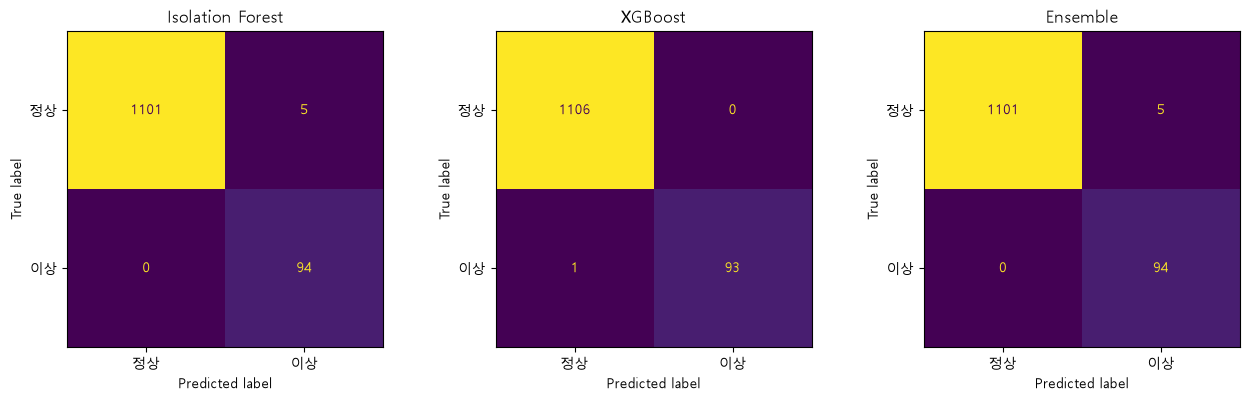

              precision    recall  f1-score   support

          정상       1.00      1.00      1.00      1106
          이상       1.00      0.99      0.99        94

    accuracy                           1.00      1200
   macro avg       1.00      0.99      1.00      1200
weighted avg       1.00      1.00      1.00      1200



In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, pred) in zip(
    axes,
    [("Isolation Forest", if_pred_test), ("XGBoost", xgb_pred_test), ("Ensemble", ensemble_pred)],
):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["정상", "이상"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

print(classification_report(y_test, xgb_pred_test, target_names=["정상", "이상"]))

## 7. SHAP 설명 — 어떤 센서가 고장을 예고하는가

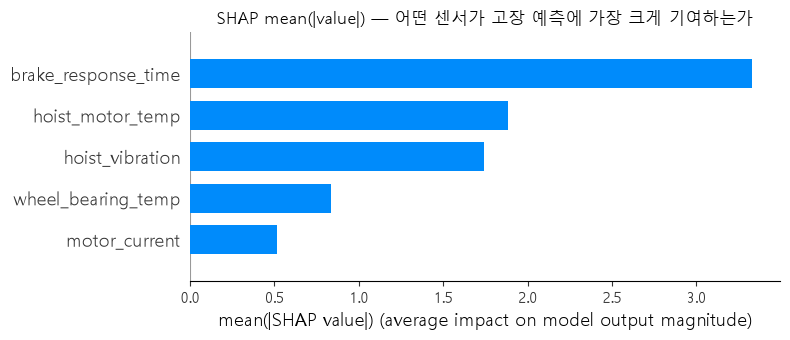

In [9]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_s)

shap.summary_plot(shap_values, X_test_s, plot_type="bar", show=False)
plt.title("SHAP mean(|value|) — 어떤 센서가 고장 예측에 가장 크게 기여하는가")
plt.tight_layout()
plt.show()

## 8. 저장

In [10]:
MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(if_model, MODELS_DIR / "amhs_vehicle_isolation_forest.joblib")
joblib.dump(xgb_model, MODELS_DIR / "amhs_vehicle_xgboost.joblib")
joblib.dump(scaler, MODELS_DIR / "amhs_vehicle_scaler.joblib")
joblib.dump(feature_cols, MODELS_DIR / "amhs_vehicle_feature_columns.joblib")
joblib.dump(best_threshold, MODELS_DIR / "amhs_vehicle_threshold.joblib")
results.to_csv(MODELS_DIR / "amhs_vehicle_pm_comparison.csv", index=False)
print("저장 완료")

저장 완료


## 결론

실행 결과(위 표)를 보고 채운다. SECOM(F1 0.228)보다 훨씬 높은 F1이 나온다면, 이는 모델이 더 좋아서가 아니라 **센서 5개짜리 규칙 기반 합성 데이터가 590개 실측 노이즈 센서보다 근본적으로 쉬운 문제이기 때문** 임을 분명히 해야 한다(노트북 05/06에서도 반복된 패턴). 이 노트북의 진짜 목적은 수치 그 자체가 아니라 **SECOM에서 검증한 파이프라인(비지도+지도 앙상블, 데이터 누출 없는 임계값 튜닝, SHAP 설명)이 도메인을 바꿔도 그대로 재사용 가능하다는 것**을 보이는 데 있다 — 실제 AMHS 현장에서 차량 센서 데이터가 쌓이기 시작하면, 이 노트북의 구조를 거의 그대로 적용할 수 있다.